In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

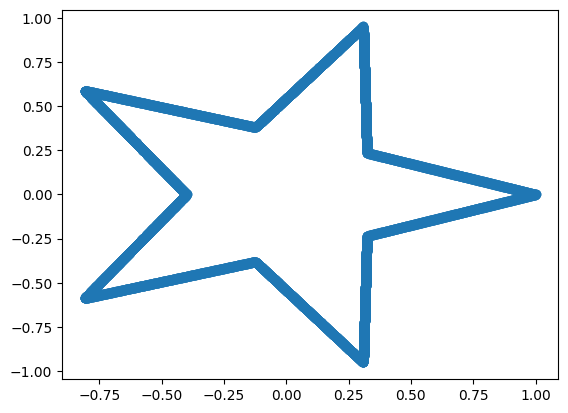

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [30]:
class Config:
    sigma_min = 0.01
    sigma_max = 4.0

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

In [10]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [48]:
def sigma_t(t, config):
    return config.sigma_min * (config.sigma_max / config.sigma_min) ** t

def g_t(t, config):
    sigma = sigma_t(t, config)
    c = math.sqrt(2.0 * math.log(config.sigma_max / config.sigma_min))

    return sigma * c

In [49]:
class VETrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            sigma = sigma_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = batch + sigma * z

            pred_z = self.model(x_t, t)
            # loss = ((sigma * pred_z + z) ** 2).sum(dim=1).mean()
            loss = F.mse_loss(pred_z, z)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            if n % 100 == 0:
                print(f'Loss: {loss}')

In [50]:
config = Config()
trainer = VETrainer(config)

In [51]:
trainer.run()

Loss: 0.9057887842178345
Loss: 0.6561680579185486
Loss: 0.645591234588623
Loss: 0.6548678525924683
Loss: 0.6204913884162903
Loss: 0.5995795317649841
Loss: 0.5946350513458252
Loss: 0.5900262341499328
Loss: 0.5851111179351807
Loss: 0.5729555084228516
Loss: 0.5699242432594299
Loss: 0.5813925203323365
Loss: 0.5832135246276855
Loss: 0.5618535135269165
Loss: 0.5510891997337342
Loss: 0.540511968421936
Loss: 0.5547446166038513
Loss: 0.5557110487937927
Loss: 0.5599110661506653
Loss: 0.5344591831207275


In [57]:
def sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device) * config.sigma_max

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            sigma = sigma_t(t_tensor, config)
            gt = g_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / sigma

            drift = (gt ** 2) * score * dt
            diffusion = gt * torch.randn_like(x) * math.sqrt(dt)

            x = x + drift + diffusion

        return x.cpu().numpy()

In [58]:
samples = sample(trainer.model, trainer.config, 1000)

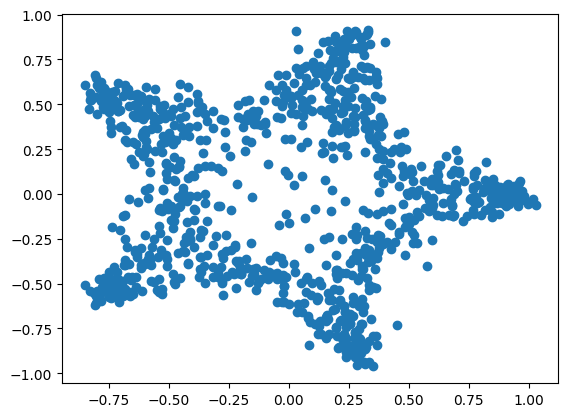

In [59]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.show()